In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [3]:
X_test.shape

(10000, 32, 32, 3)

In [4]:
X_train.shape

(50000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
y_test = y_test.reshape(-1,)

In [9]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [10]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

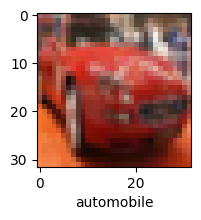

In [11]:
plot_sample(X_train, y_train, 5)

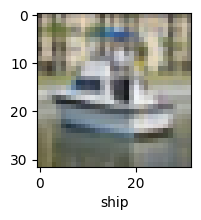

In [12]:
plot_sample(X_train, y_train, 501)

In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
ann = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Flatten(),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer = 'SGD',
            loss = 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])

ann.fit(X_train, y_train, epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 149s 95ms/step - accuracy: 0.3556 - loss: 1.8092
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 89ms/step - accuracy: 0.4287 - loss: 1.6222
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.4572 - loss: 1.5394
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 88ms/step - accuracy: 0.4770 - loss: 1.4815
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 123s 79ms/step - accuracy: 0.4950 - loss: 1.4318


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.45      0.56      0.50      1000
           1       0.64      0.52      0.57      1000
           2       0.29      0.55      0.38      1000
           3       0.40      0.29      0.34      1000
           4       0.48      0.28      0.35      1000
           5       0.54      0.24      0.33      1000
           6       0.54      0.48      0.51      1000
           7       0.58      0.51      0.54      1000
           8       0.40      0.79      0.53      1000
           9       0.65      0.36      0.47      1000

    accuracy                           0.46     10000
   macro avg       0.50      0.46      0.45     10000
weighted avg       0.50      0.46      0.45     10000



In [16]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

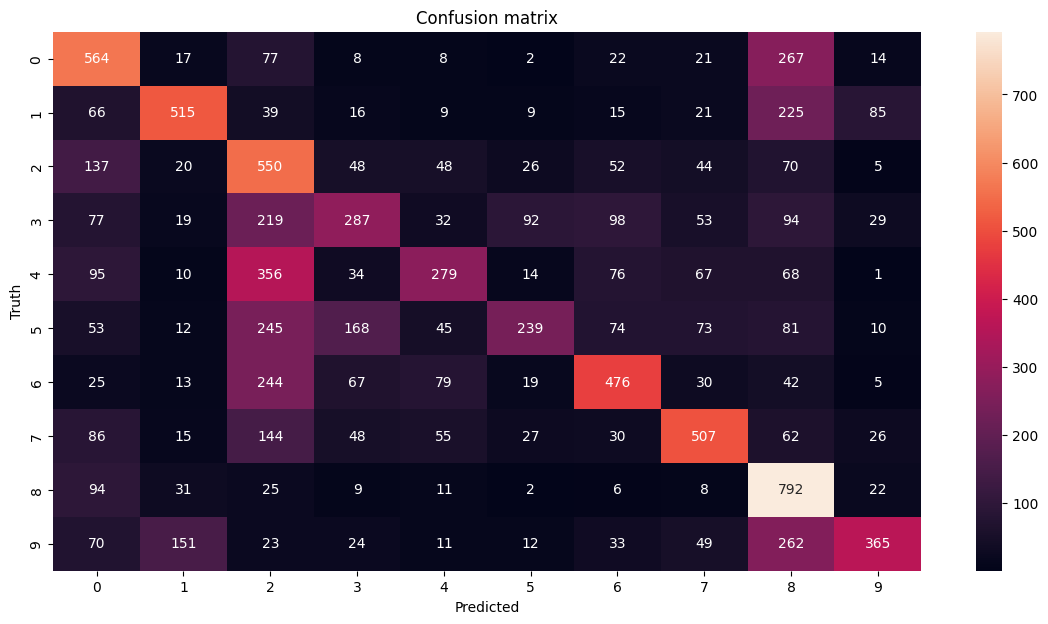

In [17]:
plt.figure(figsize = (14, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion matrix')
plt.show

In [18]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [20]:
cnn.fit(X_train, y_train, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - accuracy: 0.4852 - loss: 1.4291
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6216 - loss: 1.0799
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6663 - loss: 0.9529
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 40ms/step - accuracy: 0.6967 - loss: 0.8712
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.7210 - loss: 0.8000
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7412 - loss: 0.7412
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7611 - loss: 0.6847
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.7740 - loss: 0.6434
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - accuracy: 0.7927 - loss: 0.5959
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.8041 - loss: 0.5559


In [21]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6904 - loss: 0.9700


[0.9699939489364624, 0.6904000043869019]

In [22]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([[3.6002291e-04, 8.5944121e-05, 2.6896975e-03, 9.9170268e-01,
        1.8733534e-05, 1.7259886e-03, 3.0736988e-03, 1.4923608e-04,
        1.1001860e-04, 8.3940344e-05],
       [1.1809226e-06, 4.5466560e-04, 1.7233927e-07, 7.4177593e-09,
        1.0080592e-10, 3.0291125e-10, 4.9621280e-09, 5.7881258e-14,
        9.9952537e-01, 1.8558785e-05],
       [5.2134648e-02, 7.8879200e-02, 1.7222590e-03, 1.1895771e-02,
        5.7333702e-05, 8.3802833e-04, 1.5471224e-03, 3.6907915e-04,
        8.4841919e-01, 4.1372669e-03],
       [1.2137214e-01, 6.7679966e-03, 2.7209694e-02, 7.6954206e-04,
        9.6263466e-05, 1.0563172e-04, 8.2251830e-03, 1.3329613e-04,
        8.3253580e-01, 2.7844056e-03],
       [5.5271091e-08, 8.2010752e-07, 7.3902309e-03, 3.0244903e-03,
        3.4868589e-01, 1.2916864e-03, 6.3959712e-01, 9.1674110e-06,
        5.7020060e-07, 2.6109395e-09]], dtype=float32)

In [23]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(6)]

In [24]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

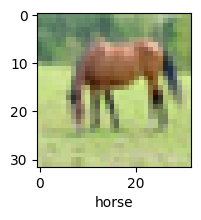

In [25]:
plot_sample(X_test, y_test, 60)

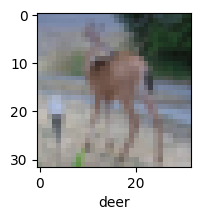

In [26]:
plot_sample(X_test, y_test, 100)

In [27]:
classes[y_classes[60]]

'horse'

### Data Augmentation Setup

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Apply random transformations to training images only (not test)
datagen = ImageDataGenerator(
    rotation_range=15,       # randomly rotate images by up to 15 degrees
    width_shift_range=0.1,   # shift image horizontally by up to 10%
    height_shift_range=0.1,  # shift image vertically by up to 10%
    horizontal_flip=True     # randomly flip images left-right
)
datagen.fit(X_train)
print("Data augmentation ready.")

Data augmentation ready.


### Enhanced CNN Architecture

In [29]:
from tensorflow.keras.layers import BatchNormalization, Dropout

cnn_new = models.Sequential([

    # Block 1 — 32 filters (two conv layers back to back)
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2 — 64 filters
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3 — 128 filters (extra layer vs original CNN)
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    # Dense head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_new.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

cnn_new.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

### Train Enhanced CNN

In [30]:
history_new = cnn_new.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 435s 548ms/step - accuracy: 0.4237 - loss: 1.6978 - val_accuracy: 0.5490 - val_loss: 1.2585
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 415s 531ms/step - accuracy: 0.5699 - loss: 1.2009 - val_accuracy: 0.6263 - val_loss: 1.0596
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 400s 512ms/step - accuracy: 0.6308 - loss: 1.0418 - val_accuracy: 0.6710 - val_loss: 0.9945
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 386s 494ms/step - accuracy: 0.6681 - loss: 0.9498 - val_accuracy: 0.6859 - val_loss: 0.8890
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 385s 493ms/step - accuracy: 0.6884 - loss: 0.8879 - val_accuracy: 0.7239 - val_loss: 0.8008
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 413s 528ms/step - accuracy: 0.7078 - loss: 0.8338 - val_accuracy: 0.7204 - val_loss: 0.8193
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 422s 540ms/step - accuracy: 0.7181 - loss: 0.8077 - val_accuracy: 0.7224 - val_loss: 0.8129
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 394s 504ms/step - accuracy: 0.7315 -

### Evaluate Enhanced CNN

In [31]:
cnn_new_loss, cnn_new_acc = cnn_new.evaluate(X_test, y_test, verbose=1)
print(f"\nEnhanced CNN — Test Accuracy : {cnn_new_acc*100:.2f}%")
print(f"Enhanced CNN — Test Loss     : {cnn_new_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7848 - loss: 0.6348

Enhanced CNN — Test Accuracy : 78.48%
Enhanced CNN — Test Loss     : 0.6348


### Comparison Table + Bar Chart

Model                   Test Accuracy       vs ANN
ANN (Baseline)                46.00%            —
CNN                           70.36%       +24.4%
Enhanced CNN                  78.48%       +32.5%


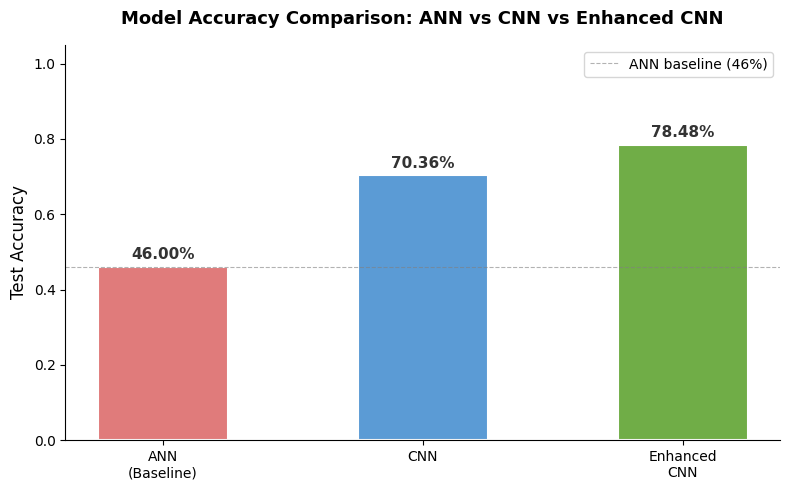

In [32]:
import matplotlib.pyplot as plt

# --- results ---
ann_acc  = 0.4600   # from classification report
cnn_acc  = 0.7036   # from cnn.evaluate()
new_acc  = cnn_new_acc  # captured above

model_names = ['ANN\n(Baseline)', 'CNN', 'Enhanced\nCNN']
accuracies  = [ann_acc, cnn_acc, new_acc]
colors      = ['#E07B7B', '#5B9BD5', '#70AD47']

# --- printed table ---
print("=" * 52)
print(f"{'Model':<20} {'Test Accuracy':>16} {'vs ANN':>12}")
print("=" * 52)
for name, acc in zip(['ANN (Baseline)', 'CNN', 'Enhanced CNN'], accuracies):
    diff = f"+{(acc - ann_acc)*100:.1f}%" if acc != ann_acc else "—"
    print(f"{name:<20} {acc*100:>14.2f}% {diff:>12}")
print("=" * 52)

# --- bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, accuracies, color=colors, width=0.5,
              edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{acc*100:.2f}%',
            ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#333333')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison: ANN vs CNN vs Enhanced CNN',
             fontsize=13, fontweight='bold', pad=15)
ax.axhline(y=ann_acc, color='grey', linestyle='--',
           linewidth=0.8, alpha=0.6, label='ANN baseline (46%)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()